# Fraud Detection Model Fintech MLOps Stack
## Notebook 4 Explainability and SHAP

This notebook covers Stage 7 of our fraud detection pipeline.

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score for every individual prediction. A positive SHAP value pushes the model toward fraud. A negative SHAP value pushes the model toward legitimate.

We generate three outputs:

**Global Feature Importance** — which features drive fraud predictions across the entire test set. This is the model's overall decision logic summarised visually.

**SHAP Summary Plot** — shows not just which features matter but how their values (high vs low) affect the fraud prediction direction.

**Per-prediction Audit Trail** — for any single transaction, a waterfall plot showing exactly how each feature contributed to that specific fraud score. This is what gets embedded in the FastAPI response for every scored transaction.

## Imports and Setup

In [1]:
# Core libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import shap
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Preprocessing (for self-contained reload) 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

# Display settings 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

shap.initjs()

print("All libraries imported successfully.")

/Users/mac/Documents/FraudDetection/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


## Load Artefacts and Rebuild Test Set

#### We load the three serialised artefacts from models/ and rerun the preprocessing pipeline to reconstruct X_test_scaled and y_test. We do not retrain anything we only need the test set to run SHAP explanations against the already-trained model.

In [2]:
# Load serialised artefacts 
ensemble_model = joblib.load('../models/ensemble_model.joblib')
scaler         = joblib.load('../models/scaler.joblib')
threshold      = joblib.load('../models/threshold.joblib')

print(f"Model loaded:     {type(ensemble_model).__name__}")
print(f"Scaler loaded:    {type(scaler).__name__}")
print(f"Threshold loaded: {threshold}")

#  Rebuild test set 
df = pd.read_csv('../data/creditcard.csv')
df = df.drop_duplicates()

df['hour']       = (df['Time'] / 3600) % 24
df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
df['amount_log'] = np.log1p(df['Amount'])
df = df.drop(['Time', 'Amount', 'hour'], axis=1, errors='ignore')

X = df.drop('Class', axis=1)
y = df['Class']

_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print(f"\nTest set shape:  {X_test_scaled.shape}")
print(f"Fraud cases:     {y_test.sum()}")

Model loaded:     StackingClassifier
Scaler loaded:    RobustScaler
Threshold loaded: 0.77

Test set shape:  (56746, 31)
Fraud cases:     95


## SHAP Explainability

#### We extract the XGBoost base model from the fitted StackingClassifier and run SHAP's TreeExplainer against the test set.

#### TreeExplainer is used specifically for tree-based models. It computes exact Shapley values using the tree structure directly far faster than the model-agnostic KernelExplainer which would take hours on 56k rows.

### We generate three outputs:
### - Global feature importance bar chart
### - SHAP summary dot plot showing value direction
### - Per-prediction waterfall plot for a single fraud case

In [3]:
# Extract XGBoost base model from the stacking ensemble 
xgb_model = ensemble_model.named_estimators_['xgb']

# Compute SHAP values using TreeExplainer 
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected:          ({X_test_scaled.shape[0]}, {X_test_scaled.shape[1]})")

SHAP values shape: (56746, 31)
Expected:          (56746, 31)


## Global Feature Importance and Summary Plots

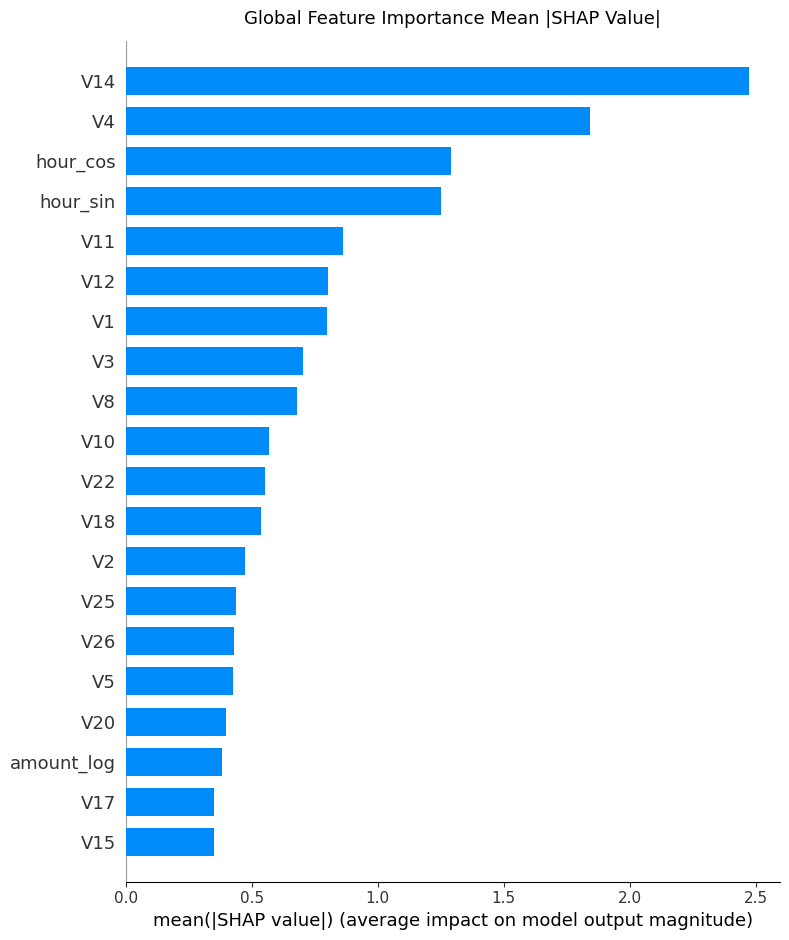

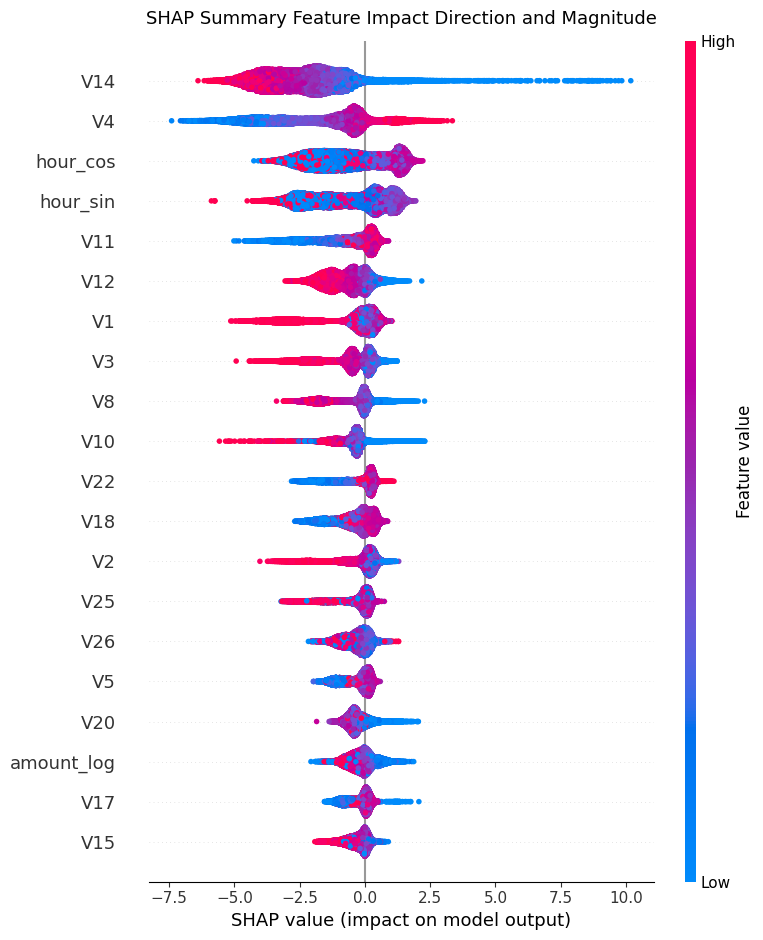

Global SHAP plots saved.


In [4]:
# Plot 1 — Global feature importance (bar) 
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance Mean |SHAP Value|', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../Plots/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2 — SHAP summary dot plot (direction + magnitude)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    show=False
)
plt.title('SHAP Summary Feature Impact Direction and Magnitude', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../Plots/shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Global SHAP plots saved.")

## Per-Prediction Audit Trail Single Transaction Waterfall Plot

#### For any individual transaction, a waterfall plot shows exactly how each feature contributed to that specific fraud score starting from the model's base rate and building up or down to the final prediction. This is the explanation that gets embedded in every FastAPI response.

Transaction index: 845
Fraud probability: 0.9998
Threshold:         0.77
Decision:          FRAUD



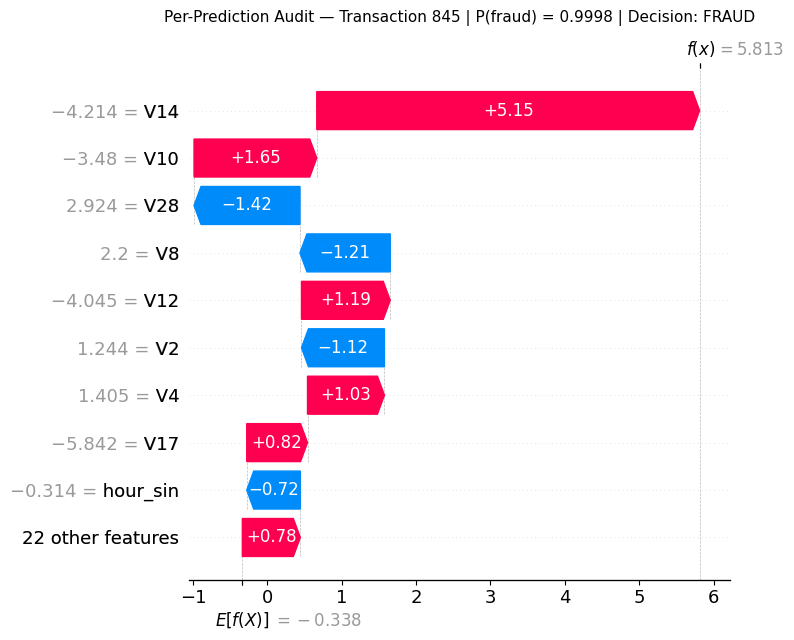

Waterfall plot saved.


In [5]:
# Find a confirmed fraud case in the test set 
fraud_indices = np.where(y_test.values == 1)[0]
transaction_idx = fraud_indices[0]

fraud_prob = ensemble_model.predict_proba(X_test_scaled)[transaction_idx, 1]
prediction = "FRAUD" if fraud_prob >= threshold else "LEGITIMATE"

print(f"Transaction index: {transaction_idx}")
print(f"Fraud probability: {fraud_prob:.4f}")
print(f"Threshold:         {threshold}")
print(f"Decision:          {prediction}")
print()

# Build SHAP Explanation object 
explanation = shap.Explanation(
    values          = shap_values[transaction_idx],
    base_values     = explainer.expected_value,
    data            = X_test_scaled.iloc[transaction_idx].values,
    feature_names   = X_test_scaled.columns.tolist()
)

# Waterfall plot for the selected transaction 
plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, show=False)
plt.title(
    f'Per-Prediction Audit — Transaction {transaction_idx} | '
    f'P(fraud) = {fraud_prob:.4f} | Decision: {prediction}',
    fontsize=11, pad=12
)
plt.tight_layout()
plt.savefig('../Plots/shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print("Waterfall plot saved.")